In [20]:
import os, json

# Créer les dossiers s'ils n'existent pas
os.makedirs(r'C:\Users\Lenovo\Desktop\deepshield\data\processed', exist_ok=True)
os.makedirs(r'C:\Users\Lenovo\Desktop\deepshield\models', exist_ok=True)
os.makedirs(r'C:\Users\Lenovo\Desktop\deepshield\results', exist_ok=True)

# Créer config.json
config = {
    "IMG_SIZE": 160,
    "MAX_IMGS": 2000,
    "n_train": 2800,
    "n_val": 600,
    "n_test": 600
}

config_path = r'C:\Users\Lenovo\Desktop\deepshield\data\processed\config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Dossiers créés")
print("✅ config.json créé :", config_path)
print("   Contenu :", config)

✅ Dossiers créés
✅ config.json créé : C:\Users\Lenovo\Desktop\deepshield\data\processed\config.json
   Contenu : {'IMG_SIZE': 160, 'MAX_IMGS': 2000, 'n_train': 2800, 'n_val': 600, 'n_test': 600}


In [21]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
PROCESSED_DIR = r'C:\Users\Lenovo\Desktop\deepshield\data\processed'
MODELS_DIR    = r'C:\Users\Lenovo\Desktop\deepshield\models'
RESULTS_DIR   = r'C:\Users\Lenovo\Desktop\deepshield\results'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(PROCESSED_DIR, 'config.json')) as f:
    cfg = json.load(f)
IMG_SIZE = cfg['IMG_SIZE']
print(f'IMG_SIZE chargé depuis config : {IMG_SIZE}')
BATCH_SIZE  = 16
EPOCHS_HEAD = 20
EPOCHS_FINE = 30
LR_HEAD     = 5e-4
LR_FINE     = 1e-5
BEST_MODEL  = os.path.join(MODELS_DIR, 'deepshield_best.keras')
print(f'TensorFlow : {tf.__version__}')
print(f'Batch size : {BATCH_SIZE} | Epochs P1: {EPOCHS_HEAD} | Epochs P2: {EPOCHS_FINE}')
print('Config OK')

IMG_SIZE chargé depuis config : 160
TensorFlow : 2.20.0
Batch size : 16 | Epochs P1: 20 | Epochs P2: 30
Config OK


In [23]:
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

print(f'X_train : {X_train.shape}  REAL:{sum(y_train==0)}  FAKE:{sum(y_train==1)}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Valeurs : min={X_train.min():.3f}  max={X_train.max():.3f}')

assert X_train.max() <= 1.0, ' Données non normalisées !'
assert X_train.shape[1] == IMG_SIZE, f' Taille images incorrecte ! Attendu {IMG_SIZE}'
print(' Données OK')

X_train : (2800, 160, 160, 3)  REAL:1400  FAKE:1400
X_val   : (600, 160, 160, 3)
X_test  : (600, 160, 160, 3)
Valeurs : min=0.000  max=1.000
 Données OK


In [24]:
def build_model(img_size=IMG_SIZE, lr=LR_HEAD):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))

    # Augmentation légère — juste ce qu'il faut sur CPU
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.08)(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='DeepShield_MobileNetV2')
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model, base

model, base_model = build_model()

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  (tête seulement)')
print(f'Frozen params    : {total - trainable:,}  (base MobileNetV2)')
print(' Modèle construit')

Total params     : 2,431,233
Trainable params : 170,689  (tête seulement)
Frozen params    : 2,260,544  (base MobileNetV2)
 Modèle construit


In [25]:
def get_callbacks(patience_es=7, patience_lr=4):
    return [
        ModelCheckpoint(
            filepath=BEST_MODEL, monitor='val_auc',
            mode='max', save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor='val_auc', patience=patience_es,
            mode='max', restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=patience_lr, min_lr=1e-7, verbose=1
        )
    ]

print(f' Callbacks OK — modèle sauvegardé dans : {BEST_MODEL}')

 Callbacks OK — modèle sauvegardé dans : C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras


In [26]:
print('='*55)
print('base gelée')
print(f'LR={LR_HEAD}  |  Batch={BATCH_SIZE}  |  Epochs max={EPOCHS_HEAD}')
print('='*55)

history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p1 = max(history1.history['val_auc'])
print(f'\n Phase 1 terminée — Meilleure val_AUC : {best_auc_p1:.4f}')
if   best_auc_p1 >= 0.75: print(' Bonne convergence — Phase 2 va améliorer')
elif best_auc_p1 >= 0.65: print('  Convergence lente — continue en Phase 2')
else:                      print(' AUC < 0.65 — vérifie les données (Cellule 2)')

base gelée
LR=0.0005  |  Batch=16  |  Epochs max=20
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5659 - auc: 0.5691 - loss: 0.7890 - precision: 0.5666 - recall: 0.6687
Epoch 1: val_auc improved from None to 0.71149, saving model to C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras

Epoch 1: finished saving model to C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 142ms/step - accuracy: 0.5832 - auc: 0.6045 - loss: 0.7443 - precision: 0.5745 - recall: 0.6414 - val_accuracy: 0.6650 - val_auc: 0.7115 - val_loss: 0.6312 - val_precision: 0.6749 - val_recall: 0.6367 - learning_rate: 5.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6474 - auc: 0.6827 - loss: 0.6614 - precision: 0.6603 - recall: 0.6553
Epoch 2: val_auc improved from 0.71149 to 0.71432, saving model to C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras

Epoch 2: finished saving model to C:\Users\Lenovo

## Fine Tuning

In [27]:
print('='*55)
print('PHASE 2 — Fine-tuning (30 dernières couches)')
print(f'LR={LR_FINE}  |  Batch={BATCH_SIZE}  |  Epochs max={EPOCHS_FINE}')
print('='*55)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Params entraînables après dégel : {trainable:,}\n')

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p2 = max(history2.history['val_auc'])
print(f'\n Phase 2 terminée — Meilleure val_AUC : {best_auc_p2:.4f}')
if best_auc_p2 >= 0.85: print(' OBJECTIF ATTEINT : AUC ≥ 0.85 ')
else:                    print(f' AUC = {best_auc_p2:.4f} — correct pour CPU + 1500 images')

PHASE 2 — Fine-tuning (30 dernières couches)
LR=1e-05  |  Batch=16  |  Epochs max=30
Params entraînables après dégel : 1,697,089



Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5961 - auc: 0.6518 - loss: 0.7291 - precision: 0.6340 - recall: 0.5142
Epoch 1: val_auc improved from None to 0.76925, saving model to C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras

Epoch 1: finished saving model to C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 157ms/step - accuracy: 0.6275 - auc: 0.6858 - loss: 0.6808 - precision: 0.6499 - recall: 0.5529 - val_accuracy: 0.5233 - val_auc: 0.7692 - val_loss: 1.2823 - val_precision: 0.5120 - val_recall: 0.9967 - learning_rate: 1.0000e-05
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6369 - auc: 0.6971 - loss: 0.6777 - precision: 0.6743 - recall: 0.5747
Epoch 2: val_auc did not improve from 0.76925
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 147ms/step - accuracy: 0.6571 - auc: 0.7175 - loss: 0.6445 - precision: 0.6771 - recall: 0.6007 - val_accuracy: 0.5133 - val_auc: 0.7621 - val_loss: 1.528

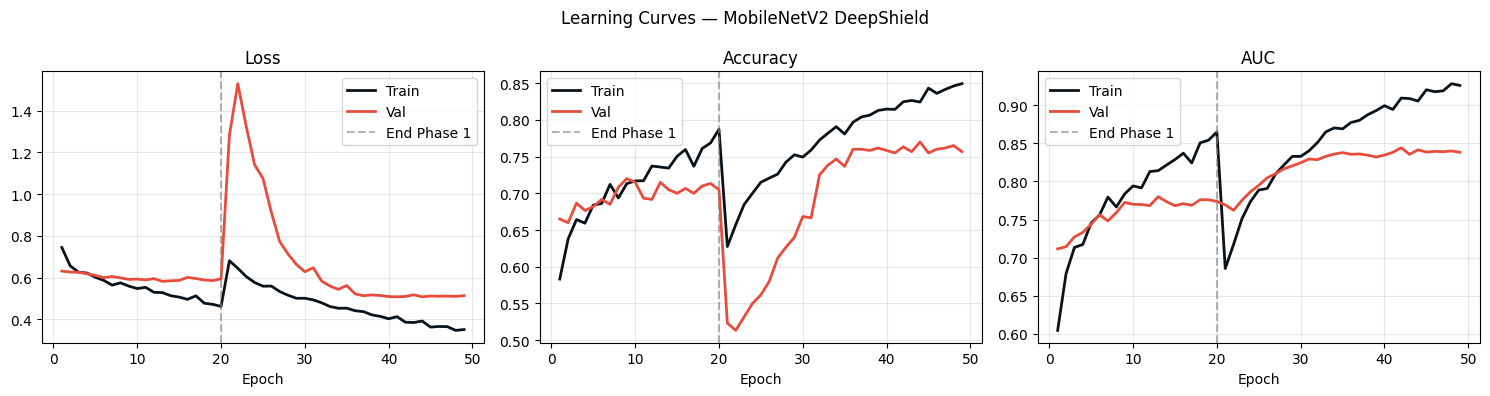

 Courbes sauvegardées.


In [ ]:
# merged = {k: history1.history[k] + history2.history[k] for k in history1.history}
# ep     = range(1, len(merged['loss']) + 1)
# p1_end = len(history1.history['loss'])

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# fig.suptitle('Learning Curves — MobileNetV2 DeepShield', fontsize=12)

# for ax, m, title in zip(axes, ['loss','accuracy','auc'], ['Loss','Accuracy','AUC']):
#     ax.plot(ep, merged[m],            label='Train', color="#0a131a", lw=2)
#     ax.plot(ep, merged[f'val_{m}'],   label='Val',   color='#e74c3c', lw=2)
#     ax.axvline(p1_end, color='gray', ls='--', alpha=0.6, label='End Phase 1')
#     ax.set_title(title); ax.set_xlabel('Epoch')
#     ax.legend(); ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=120)
# plt.show()
# print(' Courbes sauvegardées.')

In [29]:
best_model = keras.models.load_model(BEST_MODEL)
print(f' Meilleur modèle chargé : {BEST_MODEL}\n')

results      = best_model.evaluate(X_test, y_test, batch_size=16, verbose=0)
y_pred_proba = best_model.predict(X_test, batch_size=16, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)
auc_score    = roc_auc_score(y_test, y_pred_proba)

print('='*45)
print('RÉSULTATS FINAUX — Test Set')
print('='*45)
for name, val in zip(best_model.metrics_names, results):
    print(f'  {name:12s} : {val:.4f}')
print(f'  {"auc_sklearn":12s} : {auc_score:.4f}')
print('='*45)
print(f'\nDistribution des scores :')
print(f'  min={y_pred_proba.min():.4f}  max={y_pred_proba.max():.4f}  '
      f'mean={y_pred_proba.mean():.4f}  std={y_pred_proba.std():.4f}')

if y_pred_proba.std() > 0.10:
    print('\n Le modèle discrimine bien les deux classes !')
else:
    print('\n std < 0.10 — modèle pas assez convergé, augmente EPOCHS_HEAD')

 Meilleur modèle chargé : C:\Users\Lenovo\Desktop\deepshield\models\deepshield_best.keras

RÉSULTATS FINAUX — Test Set
  loss         : 0.5331
  compile_metrics : 0.7400
  auc_sklearn  : 0.8225

Distribution des scores :
  min=0.0001  max=0.9996  mean=0.5351  std=0.3253

 Le modèle discrimine bien les deux classes !


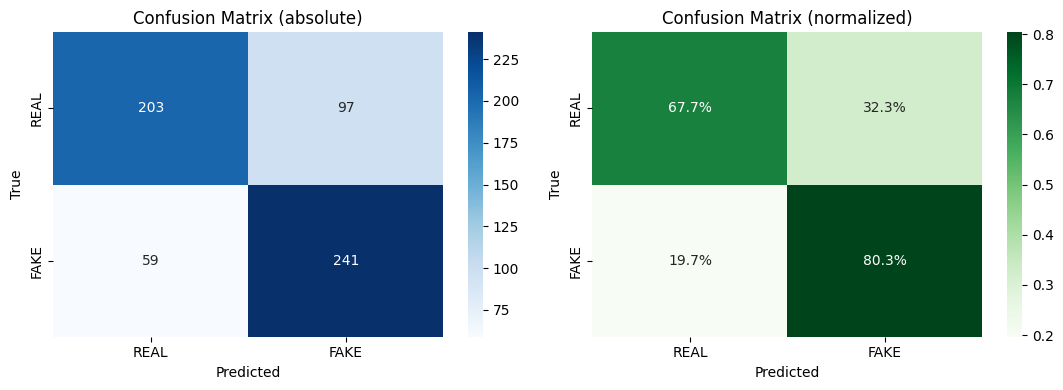

              precision    recall  f1-score   support

        REAL       0.77      0.68      0.72       300
        FAKE       0.71      0.80      0.76       300

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



In [30]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[0])
axes[0].set_title('Confusion Matrix (absolute)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()
print(classification_report(y_test, y_pred, target_names=['REAL','FAKE']))

In [31]:
final_path = os.path.join(MODELS_DIR, 'deepshield_final.keras')
best_model.save(final_path)
print(f' Modèle sauvegardé : {final_path}')

metrics_dict = dict(zip(best_model.metrics_names, results))
metrics_dict['auc_sklearn'] = auc_score
df = pd.DataFrame([metrics_dict])
csv_path = os.path.join(RESULTS_DIR, 'metrics_summary.csv')
df.to_csv(csv_path, index=False)
print(f' Métriques sauvegardées : {csv_path}')
print('\n' + df.to_string(index=False))
print('\n' + '='*50)

print('    Prochain : 03_gradcam.ipynb')
print('='*50)

 Modèle sauvegardé : C:\Users\Lenovo\Desktop\deepshield\models\deepshield_final.keras
 Métriques sauvegardées : C:\Users\Lenovo\Desktop\deepshield\results\metrics_summary.csv

    loss  compile_metrics  auc_sklearn
0.533148             0.74     0.822467

    Prochain : 03_gradcam.ipynb
